In [1]:
# BASE
# ------------------------------------------------------
import numpy as np
import pandas as pd
import warnings

# DATA VISUALIZATION
# ------------------------------------------------------
import matplotlib.pyplot as plt

# GRAPH NETWORK
# ------------------------------------------------------
from networkx import draw_networkx, DiGraph

# CASUAL INFERENCE
# ------------------------------------------------------
from causalnex.structure.notears import from_pandas
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import DiscreteFactor



# CONFIGURATIONS
# ------------------------------------------------------
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format
warnings.filterwarnings('ignore')

/Users/U192806/Documents/GitHub/causal-inference-dag/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/U192806/Documents/GitHub/causal-inference-dag/.venv/lib/python3.9/site-packages/pgmpy/utils/utils.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
class BinaryDataGenerator():

    def __init__(self, population_size : int, columns : list, random_state : int = 42):
        self.random_state = random_state
        self.__data = pd.DataFrame(data=np.full(shape=(population_size, len(columns)), fill_value=0, dtype=int), columns=columns)

    def set_values(self, col_name : str, count : int = None, frac : float = None, condition : pd.Series = None, value = 1):
        if condition is None: # If no condition specified, create a dummy condition that is True for every row so the update will be applies to all rows
            condition = pd.Series(data=[True] * len(self.__data))

        update_indices = list(self.__data[condition].sample(n=count, frac=frac, random_state=self.random_state).index)
        self.__data.loc[update_indices, [col_name]] = value

    @property
    def data(self) -> pd.DataFrame:
        return self.__data

    @property
    def summary(self) -> pd.DataFrame:
        return self.__data.value_counts().reset_index().rename({0:"Count"}, axis=1)

In [3]:
# Generate the Data
POPULATION_SIZE = 1_000_000
RANDOM_STATE = 42
FEATURES = ['Vaccination?', 'Reaction?', 'Smallpox?', 'Death?']

smallpox_dataset = BinaryDataGenerator(population_size=POPULATION_SIZE, columns=FEATURES, random_state=42) # The disease data contains 1m rows and 4 columns
data = smallpox_dataset.data

smallpox_dataset.set_values(col_name="Vaccination?", frac=0.99, condition=None) # 99% of the population get the vaccination
smallpox_dataset.set_values(col_name="Reaction?", frac=0.01, condition=data["Vaccination?"]==1) # 1% of those vaccinated get a reaction
smallpox_dataset.set_values(col_name="Death?", frac=0.01, condition=data["Reaction?"]==1) # 1% of those who get a reaction die
smallpox_dataset.set_values(col_name="Smallpox?", frac=0.02, condition=data["Vaccination?"]==0) # 2% of those who do not get vaccinated get the Smallpox
smallpox_dataset.set_values(col_name="Death?", frac=0.2, condition=data["Smallpox?"]==1) # 20% of those who get Smallpox die from it

print(smallpox_dataset.data.shape)
df_summary = smallpox_dataset.summary
df_summary

(1000000, 4)


,Vaccination?,Reaction?,Smallpox?,Death?,Count
0,1,0,0,0,980100
1,1,1,0,0,9801
2,0,0,0,0,9800
3,0,0,1,0,160
4,1,1,0,1,99
5,0,0,1,1,40


In [5]:
smallpox_dataset.data

,Vaccination?,Reaction?,Smallpox?,Death?
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0
...,...,...,...,...
999995,1,0,0,0
999996,1,0,0,0
999997,1,0,0,0
999998,1,0,0,0


In [4]:
print(f'Deaths caused by Vaccination: {df_summary.iloc[4]["Count"]}')
print(f'Deaths caused by Smallpox: {df_summary.iloc[5]["Count"]}')

Deaths caused by Vaccination: 99
Deaths caused by Smallpox: 40


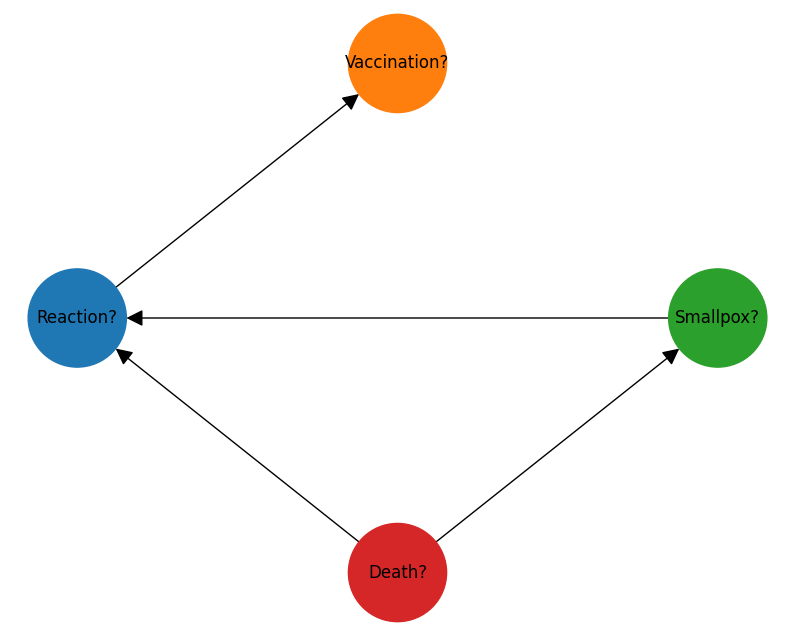

In [6]:
def plot_model(model, pos : dict = None, figsize : tuple = (10, 8), node_size : int = 5000):
    plt.figure(figsize=figsize) 
    plt.box(False)
    draw_networkx(DiGraph(model.edges), with_labels=True, pos=pos, node_color=['C{}'.format(i) for i in range(len(pos))], node_size=node_size, arrowsize=25)
    plt.show()
    
POS : dict = {'Vaccination?': np.array([0, 1]), 'Reaction?': np.array([-1, 0]), 'Smallpox?': np.array([1, 0]), 'Death?': np.array([0, -1])}
FIGSIZE : tuple = (10, 8)

# Use the NOTEARS algorithm to attempt to infer the Directed Acyclic Graph from the data ...
notears_model = from_pandas(smallpox_dataset.data, w_threshold=0.1)
plot_model(model=notears_model, pos=POS, figsize=FIGSIZE)

## What is a DAG?

DAG stands for **Directed Acyclic Graph**

1) **Graph** - a graph is a structure consisting of two parts *Nodes* and *Edges*

2) **Directed** - means that the edges have a direction

3) **Acyclic** - this is the crucial part in a DAG, means that there are no *cycles* in the graph. A -> B, B -> C, C -> A

If A causes B, and B causes C, then C canot cause A, because that would imply A causes A which does not make sense causally


## Why do we want DAG?

1) Causal Discovery
    * uncover cause and effect relationships
    * unlike correlation matrices that just tells you two variables are correlated, but DAG tells you *how* they are related
    * identifying direct vs. indirect effects (e.g. A -> B -> C means A indirectly affects C through B)
2) Confounding Control and Bias Identification
3) Understanding Data Generating Processes
    * provides a visual and mathematical model of how the data you observe was generated
    * clarifies the dependencies between variables, showing which variables influence others and in what order
4) Prediction and Intervention
    * standard ML focus on prediction based on correlations, a causal DAG can lead to more robus predictions, especially when the undelrying data distribution changes or when you want to predict the outcome of an intervention
    * simulate intervations (e.g. What if we increased variable X by 10%?)
5) Hypothesis Generation and Refinement
6) Data Engineering and Workflow Orchestration

In summary, the core purpose of finding a DAG in a dataset, particularly in a causal context, is to move beyond mere statistical association to understand the underlying causal mechanisms. This deeper understanding enables more accurate predictions, better decision-making, and robust solutions to real-world problems.

**Causal Discovery**

* Constraint-Based Methods
    * performs a series of conditional independence tests
    * by adding or removing edges based on statistical dependencies
    * examples - PC Algorithm, Grow-Shrink Algorithm
* Score-Based Methods
    * define a "score" for each possible DAG, which measure how well teh DAG fits the data
    * examples - Hill Climbing, Greedy Equivalence Search
* Functional Causal Model / Equation-Based Methods
    * leverage the properties of the error terms to infer directionality
    * examples - NOTEARS

* Combinatorial Problem
    * Characteristics 
        * You can only deal in discrete choice (0 or 1)
        * Difficult to explore different branches of possibilities, which can be computationally very expensive
            * A -> B -> C -> D -> E -> F
            * A -> B -> C -> D -> E -> G
* Continuous Optimization Problem
    * Characteristics
        * variables can take on any real value within a given range
        * Infinite search space
        * Because of the continuous variable function, it can be differentiated - Gradient-based 
            * f(x)=x2−4x+5
                * find where its derivative is zero

## NOTEARS

NOTEARS algorithm is being used for causal discovery. NOTEARS (Non-linear Optimization for ADjacency Estimation in RLS) is an algorithm designed to learn the structure of a DAG from observational data by formulating it as a continuous optimization problem.

```python
causalnex.structure.notears.from_pandas
```

* converts the problem of learning DAG which is inherently combinatorial (1 or 0), rephrases it mathematically so that it can be solved using continuous optimization techniques

* Characteristics
    * Representing edge with continuous weights
        * instead of 0 or 1
        * if the weight is close to zero, it means no edge
    * A differentiable acyclicity constraint
        * develops a continuous and differentiable mathematical function that equals zero if and only if the graph formed by these continuous weights is a DAG
    * Minimizing the continuous objective function
        1) how well the graph explains the observed data
        2) How sparse the graph is (how few edges it has)
        3) The requirement that the graph must be a DAG (using the special acyclicity function)
        
By doing this, NOTEARS avoids the brute-force, discrete search over an exponentially growing number of DAGs

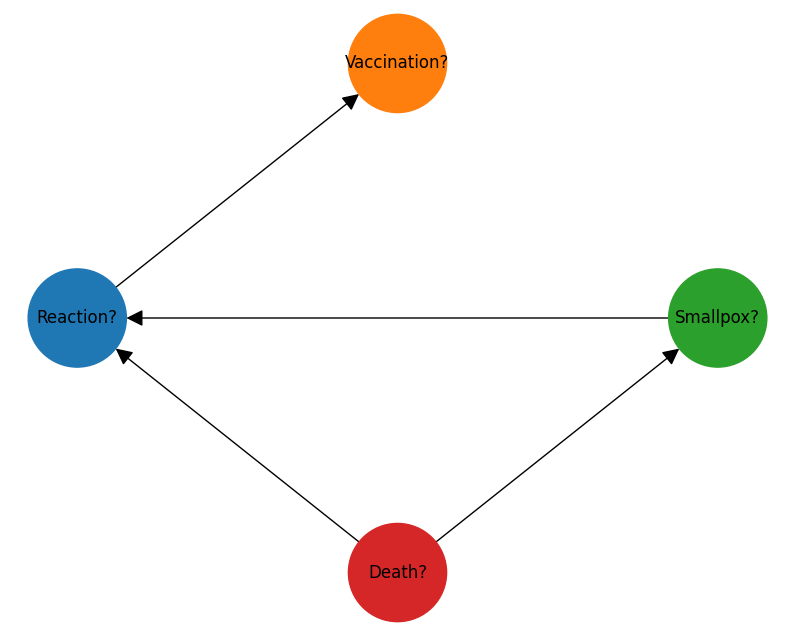

In [8]:
from IPython.display import Image, display
file_path = 'plots/output.png'
display(Image(filename=file_path))

## What's wrong?

In the book *The Book of Why - The New Science of Cause and Effect* by *Judea Pearl*, she argues that causal diagram requires domain expertise and cannot be simply inferred from the data.

* "Unsuitability of NOTEARS for Causal Graph Discovery" - Marcus Kaiser, Maksim Sipos

e.g. An observation of roosters crowing and sun rising could infer that there is a correlation between the two, but a rooster does not cause the sun to rise.


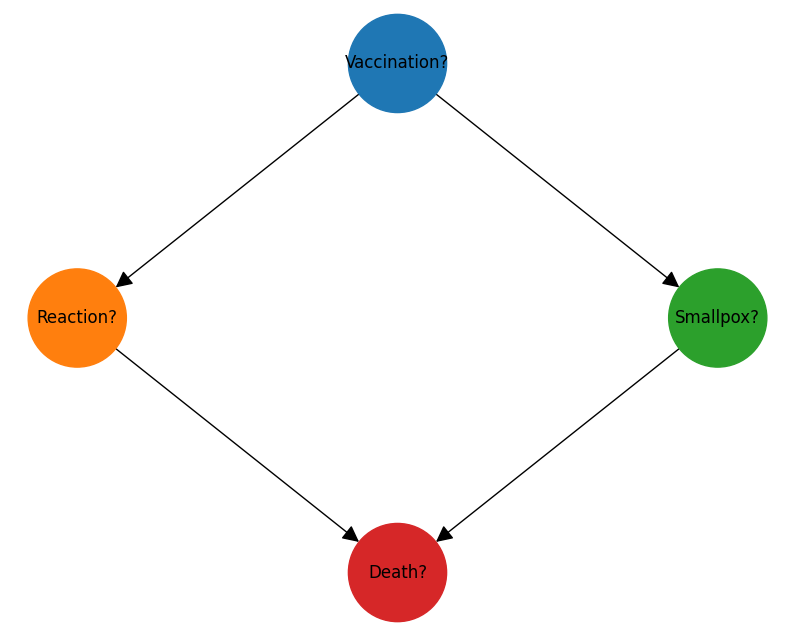

In [9]:

# Use domain knowledge to specify the Directed Acyclic Graph from experience and expertise  ...
domain_model = BayesianNetwork([('Vaccination?', 'Reaction?'), ('Vaccination?', 'Smallpox?'), ('Reaction?', 'Death?'), ('Smallpox?', 'Death?')])
plot_model(model=domain_model, pos=POS, figsize=FIGSIZE)

## Conditional Probability Tables

In [10]:
domain_model.fit(smallpox_dataset.data)
domain_model.check_model()

True

In [12]:
for cpd in domain_model.get_cpds():
    print(cpd)

+-----------------+------+
| Vaccination?(0) | 0.01 |
+-----------------+------+
| Vaccination?(1) | 0.99 |
+-----------------+------+
+--------------+-----------------+-----------------+
| Vaccination? | Vaccination?(0) | Vaccination?(1) |
+--------------+-----------------+-----------------+
| Reaction?(0) | 1.0             | 0.99            |
+--------------+-----------------+-----------------+
| Reaction?(1) | 0.0             | 0.01            |
+--------------+-----------------+-----------------+
+--------------+-----------------+-----------------+
| Vaccination? | Vaccination?(0) | Vaccination?(1) |
+--------------+-----------------+-----------------+
| Smallpox?(0) | 0.98            | 1.0             |
+--------------+-----------------+-----------------+
| Smallpox?(1) | 0.02            | 0.0             |
+--------------+-----------------+-----------------+
+-----------+--------------+--------------+--------------+--------------+
| Reaction? | Reaction?(0) | Reaction?(0) | React

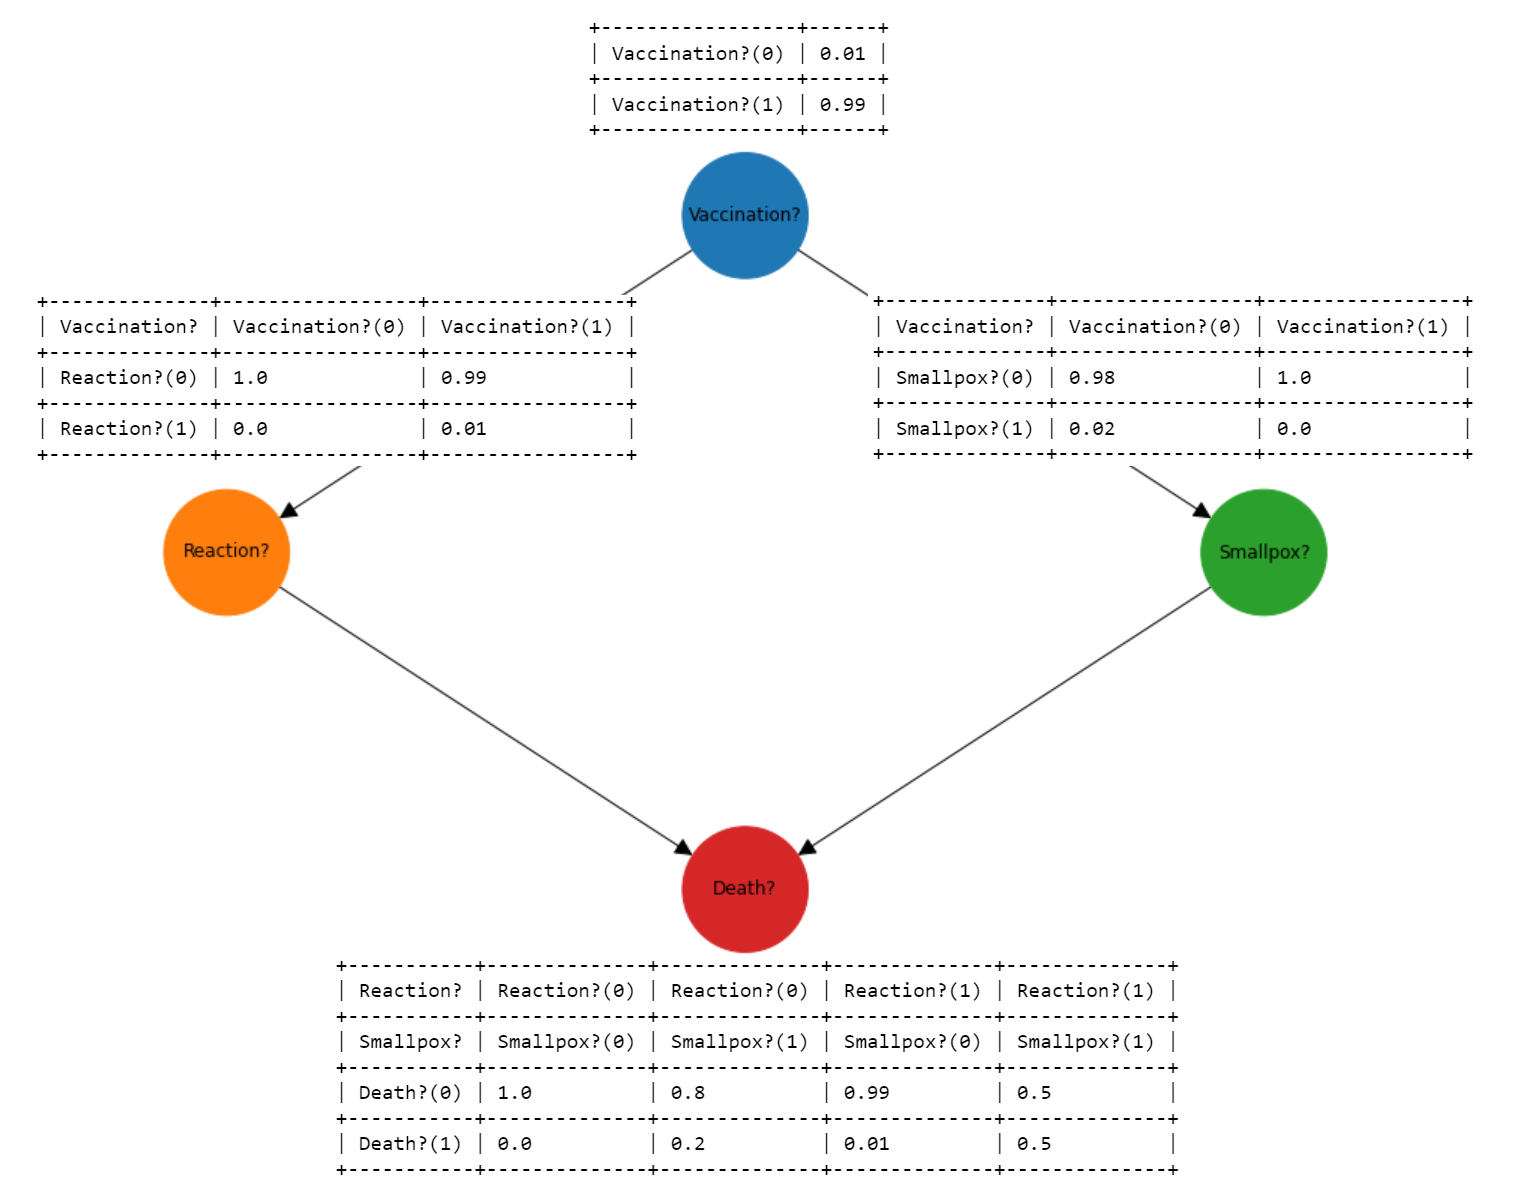

In [13]:
from IPython.display import Image, display
file_path = 'plots/cpd.png'
display(Image(filename=file_path))

In [14]:
def execute_query(model : BayesianNetwork, variables : list, evidence : list = None, verbose : bool = True) -> DiscreteFactor:
    query = VariableElimination(model).query(variables, evidence, show_progress=False)
    if verbose:
        print(query)
    return query

1) What are the total number of deaths?

In [15]:
q1 = execute_query(domain_model, variables=['Death?'], evidence=None)
print(f"Number of deaths: {int(q1.values[1] * POPULATION_SIZE)}")

+-----------+---------------+
| Death?    |   phi(Death?) |
+===========+===============+
| Death?(0) |        0.9999 |
+-----------+---------------+
| Death?(1) |        0.0001 |
+-----------+---------------+
Number of deaths: 139


2) What would have happened if there had not been a vaccination programme?

In [16]:

q2 = execute_query(domain_model, variables=['Death?'], evidence={'Vaccination?': 0})
print(f"Number of deaths: {q2.values[1] * POPULATION_SIZE}")
print(f"Lives saved by vaccine program: {int((q2.values[1] * POPULATION_SIZE) - (q1.values[1] * POPULATION_SIZE))}")

+-----------+---------------+
| Death?    |   phi(Death?) |
+===========+===============+
| Death?(0) |        0.9960 |
+-----------+---------------+
| Death?(1) |        0.0040 |
+-----------+---------------+
Number of deaths: 4000.0
Lives saved by vaccine program: 3861


3) What would have happened if, instead of 99%, the vaccination rate had been 50%?

In [18]:
print(domain_model.get_cpds("Vaccination?"))


+-----------------+------+
| Vaccination?(0) | 0.01 |
+-----------------+------+
| Vaccination?(1) | 0.99 |
+-----------------+------+


In [19]:
cpd_v = TabularCPD(variable='Vaccination?', variable_card=2, values=[[0.5], [0.5]])
domain_model.add_cpds(cpd_v) # This replaces the existing CPT
print(domain_model.get_cpds("Vaccination?"))

+-----------------+-----+
| Vaccination?(0) | 0.5 |
+-----------------+-----+
| Vaccination?(1) | 0.5 |
+-----------------+-----+


In [20]:
q3 = execute_query(domain_model, variables=['Death?'], evidence=None)
print(f"Number of deaths: {int(q3.values[1] * POPULATION_SIZE)}")

+-----------+---------------+
| Death?    |   phi(Death?) |
+===========+===============+
| Death?(0) |        0.9980 |
+-----------+---------------+
| Death?(1) |        0.0021 |
+-----------+---------------+
Number of deaths: 2050
